> # Courbes paramétrées: le vecteur vitesse
>
> ## Vecteur vitesse ou vecteur dérivé; tangentes; points singuliers

> Si $M: I \to \R^2$ est une courbe paramétrée,
> qui à $t$ associe le point $M(t)$ du plan,
> il lui correspond deux fonctions coordonnées:
>
> - $x: I \to \R$ qui à $t$ associe l'abscisse au temps $t$
> - $y: I \to \R$ qui à $t$ associe l'ordonnée au temps $t$


> On dit que la courbe paramétrée est dérivable si les deux fonctions coordonnées le sont.
>
> Le vecteur dérivé en $t = a$ de la courbe $M$ est le vecteur $M'(a)$, de coordonnées $(x'(a), y'(a))$.
>
> Une courbe dérivable au temps $t = a$ est
>
> - régulière au temps $t = a$ si son vecteur dérivé au temps $t = a$ n'est pas nul.
> - singulière au temps $t = a$ si son vecteur dérivé au temps $t = a$ est nul.
>
> En un point régulier, le vecteur vitesse fournit un vecteur directeur de la tangente.
>
> En un point singulier, un développement limité des coordonnées de la courbe permet de trouver un vecteur directeur de la tangente.

> ## Cycloïde

> On considère un cercle de rayon $r$ qui roule sans glisser
> le long d'une droite, en parcourant toute la droite.
>
> En suivant la position d'un point de la circonférence du cercle
> au cours de ce mouvement, on obtient une courbe appelée cycloïde.
>
> On prend
>
> - comme origine le point $O$ de contact au temps $t = 0$
> - comme axe des abscisses la droite sur laquelle roule le cercle;
>   on oriente cet axe dans le sens de déplacement du cercle
> - comme axe des ordonnées la droite normale à l'axe des abscisses;
>   on oriente cet axe depuis le point de contact initial
>   vers la position initiale du centre du cercle
>
> On note, au temps $t$,
>
> - $H(t)$ le point de contact du cercle et de la droite
> - $C(t)$ la position du centre du cercle
> - $M(t)$ la position du point de la circonférence du cercle
>   qui était en contact au temps $t = 0$
>
> On suppose que le mouvement s'effectue de telle sorte que
> le cercle roule à vitesse angulaire constante.
>
> Par notre choix de repère, le mouvement est vers les abscisses croissantes.
> La rotation du cercle est donc dans le sens horaire (sens trigonométrique inverse).
>
> On suppose que la vitesse angulaire est $-1$.

> Un paramétrage de la cycloïde est, comme vu en exercice papier:
$$
M(t) = \begin{bmatrix}r t - r \sin(t)\\ 1 - r \cos(t)\\ \end{bmatrix}
$$

> Définissons avec Sage une fonction qui prend en entrée
> le rayon $r$ et qui renvoie les deux fonctions coordonnées.

In [8]:
def cycloide(r):
    r"""
    Renvoie un paramétrage de la cycloïde de rayon `r`.
    """
    x(t) = r*t - r*sin(t)
    y(t) = r - r*cos(t)
    M(t) = (x(t), y(t))
    return M

> Prenons par exemple pour rayon $r = 2$.

In [9]:
r = 2

In [10]:
M = cycloide(r)

In [11]:
M

t |--> (2*t - 2*sin(t), -2*cos(t) + 2)

> On peut évaluer $M$ en $t$ avec $t$ symbolique, ou avec $t$ un nombre.

In [12]:
t = SR.var('t')
M(t)

(2*t - 2*sin(t), -2*cos(t) + 2)

In [13]:
M(pi)

(2*pi, 4)

> Points de la courbe pour quelques valeurs de $t$

In [14]:
M(0), M(pi/4), M(pi/2), M(pi)

((0, 0), (1/2*pi - sqrt(2), -sqrt(2) + 2), (pi - 2, 2), (2*pi, 4))

> On a vu dans la première séance sur machine comment tracer une courbe paramétrée avec Sage.

In [15]:
courbe_cycloide = parametric_plot(M, (-3*pi, 5*pi), color='red', ticks=pi, tick_formatter=pi)

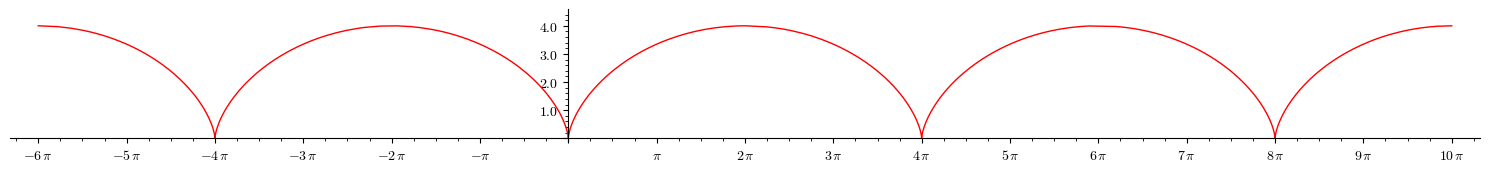

In [16]:
courbe_cycloide.show(figsize=15, ymax=2.25*r)

> ### Vecteur vitesse
>
> Voici une fonction `derivee_vectorielle` qui, partant d'un paramétrage de courbe,
> renvoie un paramétrage du vecteur vitesse.

In [17]:
def derivee_vectorielle(M):
    t = SR.var('t')
    vt =  tuple(diff(M(t), t))
    v(t) = vt
    return v

In [18]:
v_M = derivee_vectorielle(M)
v_M

t |--> (-2*cos(t) + 2, 2*sin(t))

In [19]:
v_M(0)

(0, 0)

In [20]:
v_M(pi/2)

(2, 2)

In [21]:
v_M(pi)

(4, 0)

> On trace la cycloïde et quelques vecteurs tangents unitaires.

In [22]:
vecteurs_tangents = {t: v_M(t) / v_M(t).norm() for t in srange(0, 2*pi, pi/4) if v_M(t) != 0}

In [23]:
fleches = [u.plot(start=M(t), arrowsize=2) for t, u in vecteurs_tangents.items()]

In [24]:
courbe_avec_fleches = sum(fleches, courbe_cycloide)

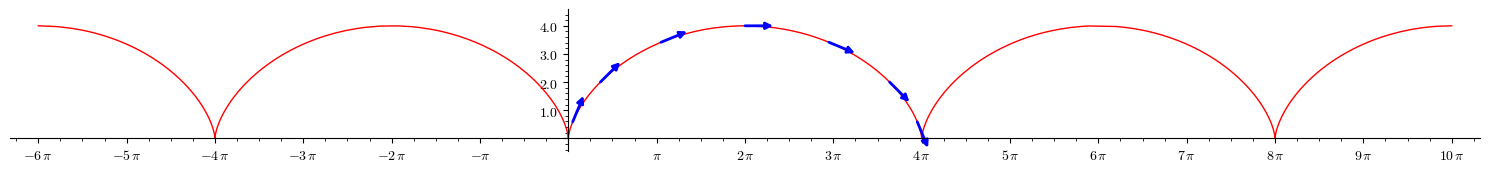

In [25]:
courbe_avec_fleches.show(figsize=15, ymax=4.5, ticks=pi, tick_formatter=pi)

> ## Une courbe de degré 5

> **Exercice.**
>
> On considère la courbe définie par $x(t) = t^5 - 4 t^3$ et $y(t) = t^2$.
>
> - Quel est son domaine de définition?
> - Tracez sommairement la courbe. Quel intervalle avez-vous utilisé?
> - Calculez le vecteur dérivé en chaque point.
> - Déterminez le point singulier.
> - Calculez une équation de la tangente au point $(3, 1)$.
> - Calculez les équations des deux tangentes au point $(0, 4)$.
> - Tracez la courbe avec quelques vecteurs tangents.


In [3]:
# domaine de définition : R^2

In [1]:
courbe_deg_5(t) = (t^5 -4*(t^3), t^2)

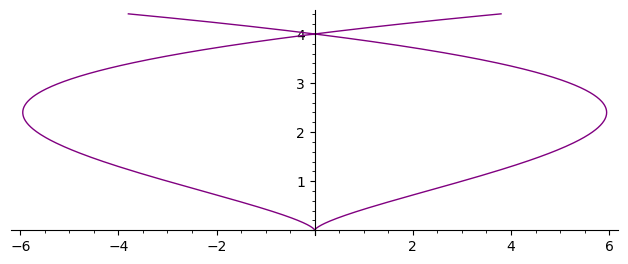

In [4]:
courbe_courbe5 = parametric_plot(courbe_deg_5, (-2.1, 2.1), color='purple')
courbe_courbe5.show()

In [7]:
courbe_deg_5(-t) # la fonction x(t) est impaire et la fonction y(t) est paire, donc M(-t)=(-x(t),y(t))

(-t^5 + 4*t^3, t^2)

In [8]:
derivee_vectorielle_courbe5 =  tuple(diff(courbe_deg_5(t), t))
derivee_vectorielle_courbe5

(5*t^4 - 12*t^2, 2*t)

In [9]:
solve([derivee_vectorielle_courbe5[0]==0],[t])

[t == -2/5*sqrt(5)*sqrt(3), t == 2/5*sqrt(5)*sqrt(3), t == 0]

In [10]:
solve([derivee_vectorielle_courbe5[1]==0],[t])

[t == 0]

In [11]:
Point_singulier = solve([derivee_vectorielle_courbe5[0]==0, derivee_vectorielle_courbe5[1]==0],[t])
Point_singulier

[[t == 0]]

In [12]:
courbe_deg_5(0)

(0, 0)

In [23]:
solve([courbe_deg_5[0]==3,courbe_deg_5[1]==1],[t])

[[t == -1]]

In [25]:
M1 = courbe_deg_5(-1)
M1

(3, 1)

In [26]:
solve([courbe_deg_5[0]==0,courbe_deg_5[1]==4],[t])

[[t == -2], [t == 2]]

In [27]:
M2 = courbe_deg_5(2)
M2

(0, 4)

In [28]:
M3 = courbe_deg_5(-2)
M3

(0, 4)

In [22]:
# Autre méthode / technique pour évaluer la dérivée en un point t quelconque

In [16]:
t = SR.var('t')

x(t) = t**5 - 4*t**3
y(t) = t**2
M(t) = (x(t), y(t))

In [18]:
def derivee_vectorielle(M):
    t = SR.var('t')
    vt =  tuple(diff(M(t), t))
    v(t) = vt
    return v
v_M = derivee_vectorielle(M)

In [29]:
vt_M1 = v_M(-1)
M1, vt_M1

((3, 1), (-7, -2))

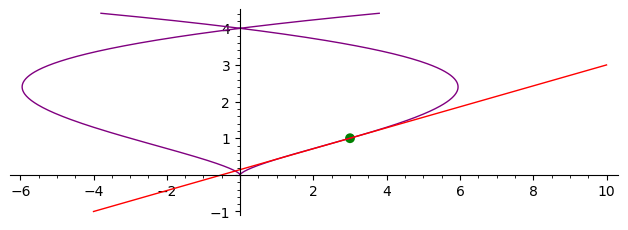

In [21]:
droite_tangente = line([M1 - vt_M1, M1 + vt_M1],color='red')
P = point([M1], size = 50, color = 'green')
courbe_courbe5 + droite_tangente + P

In [30]:
vt_M2 = v_M(2)
vt_M3 = v_M(-2)
vt_M2, vt_M3

((32, 4), (32, -4))

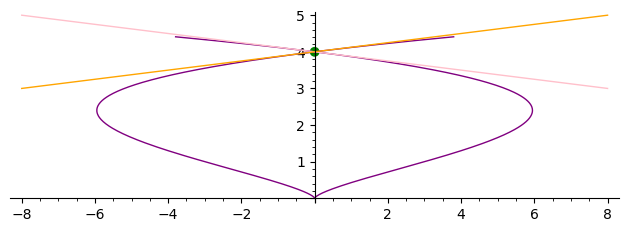

In [31]:
droite_tangente1 = line([M3 - 1/4 * vt_M3, M3 + 1/4 * vt_M3], color = 'pink')
droite_tangente2 = line([M2 - 1/4 * vt_M2, M2 + 1/4 * vt_M2], color = 'orange')
P1 = point([M3], size = 50, color = 'green')
courbe_courbe5 + droite_tangente1 + droite_tangente2 + P1

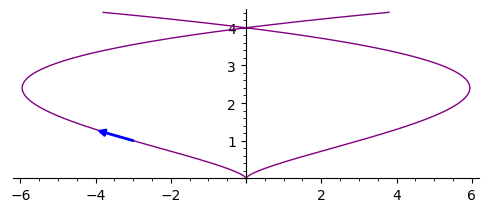

In [37]:
vecteurs_tangents = {t: v_M(t) / v_M(t).norm() for t in srange(1, 5, 6) if v_M(t) != 0}
fleches = [u.plot(start=M(t), arrowsize=2) for t, u in vecteurs_tangents.items()]
courbe_avec_fleches = sum(fleches, courbe_courbe5)
courbe_avec_fleches.show(figsize=5)